#1. Import Bibliotek

In [1]:
%pip install pandas numpy matplotlib seaborn missingno scikit-learn jupyter ipykernel
import os
import pandas as pd
import seaborn as sns
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Car_sale_ads.csv", sep=",")
print(df)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


         Index  Price Currency Condition Vehicle_brand Vehicle_model  \
0            0  86200      PLN       New        Abarth           595   
1            1  43500      PLN      Used        Abarth         Other   
2            2  44900      PLN      Used        Abarth           500   
3            3  39900      PLN      Used        Abarth           500   
4            4  97900      PLN       New        Abarth           595   
...        ...    ...      ...       ...           ...           ...   
208299  208299  39900      PLN      Used           Żuk         Other   
208300  208300  10900      PLN      Used           Żuk         Other   
208301  208301   6900      PLN      Used           Żuk         Other   
208302  208302   5700      PLN      Used           Żuk         Other   
208303  208303  11900      PLN      Used           Żuk         Other   

       Vehicle_version Vehicle_generation  Production_year  Mileage_km  ...  \
0                  NaN                NaN             20

#2. Spojrzenie ogólne na braki danych

In [2]:
df.isnull().any()

Index                      False
Price                      False
Currency                   False
Condition                  False
Vehicle_brand              False
Vehicle_model              False
Vehicle_version             True
Vehicle_generation          True
Production_year            False
Mileage_km                  True
Power_HP                    True
Displacement_cm3            True
Fuel_type                  False
CO2_emissions               True
Drive                       True
Transmission                True
Type                       False
Doors_number                True
Colour                     False
Origin_country              True
First_owner                 True
First_registration_date     True
Offer_publication_date     False
Offer_location             False
Features                   False
dtype: bool

In [3]:
data = df.copy()
missing_summary = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_%": data.isna().mean() * 100,
    "dtype": data.dtypes.astype(str)
}).sort_values("missing_%", ascending=False)

missing_only = missing_summary[missing_summary["missing_count"] > 0]
display(missing_only)

,missing_count,missing_%,dtype
First_owner,143210,68.750480,object
First_registration_date,121859,58.500557,object
CO2_emissions,114257,54.851083,float64
Origin_country,89992,43.202243,object
Vehicle_version,70222,33.711307,object
Vehicle_generation,60444,29.017206,object
Drive,15076,7.237499,object
Displacement_cm3,1966,0.943813,float64
Doors_number,1487,0.713861,float64
Mileage_km,983,0.471906,float64


In [4]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
date_cols = data.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print("Liczba kolumn numerycznych:", len(num_cols))
print("Liczba kolumn kategorycznych:", len(cat_cols))
print("Liczba kolumn datowych:", len(date_cols))

print("\nNumeryczne:")
print(num_cols)

print("\nKategoryczne:")
print(cat_cols)

print("\nDatowe:")
print(date_cols)

Liczba kolumn numerycznych: 8
Liczba kolumn kategorycznych: 17
Liczba kolumn datowych: 0

Numeryczne:
['Index', 'Price', 'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3', 'CO2_emissions', 'Doors_number']

Kategoryczne:
['Currency', 'Condition', 'Vehicle_brand', 'Vehicle_model', 'Vehicle_version', 'Vehicle_generation', 'Fuel_type', 'Drive', 'Transmission', 'Type', 'Colour', 'Origin_country', 'First_owner', 'First_registration_date', 'Offer_publication_date', 'Offer_location', 'Features']

Datowe:
[]


#3. EDA

#3.1 Braki danych

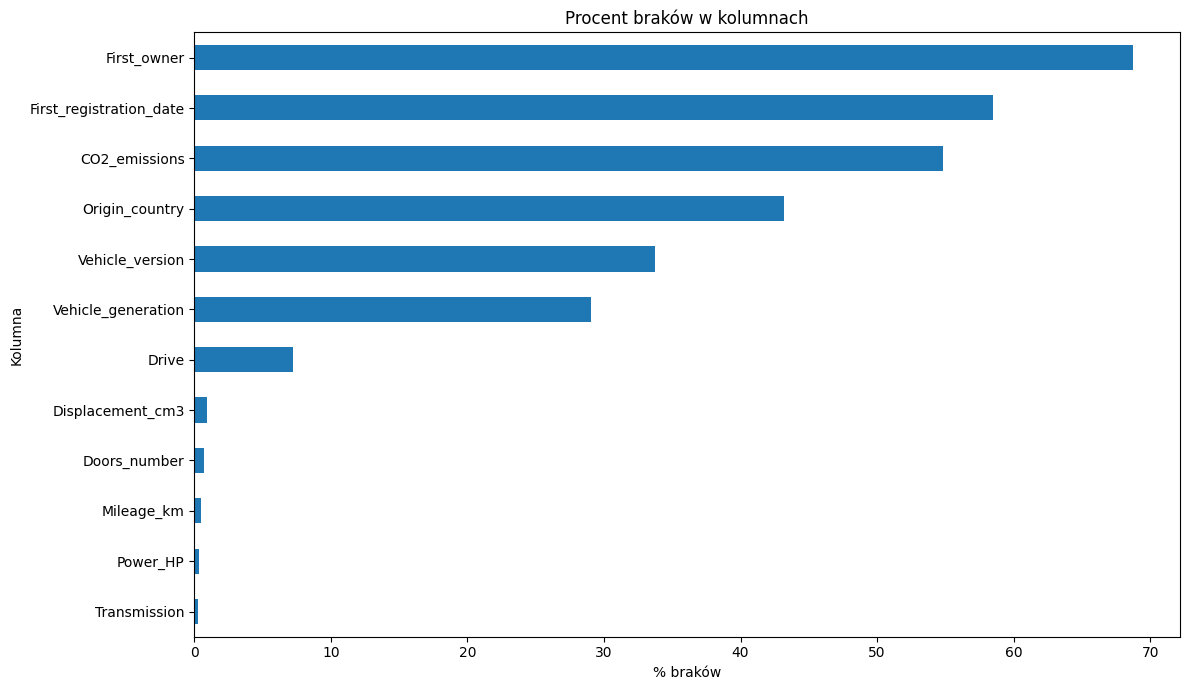

In [5]:
missing_only = missing_summary[missing_summary["missing_count"] > 0]
plt.figure(figsize=(12, 7))
missing_only["missing_%"].sort_values().plot(kind="barh")
plt.title("Procent braków w kolumnach")
plt.xlabel("% braków")
plt.ylabel("Kolumna")
plt.tight_layout()
plt.show()


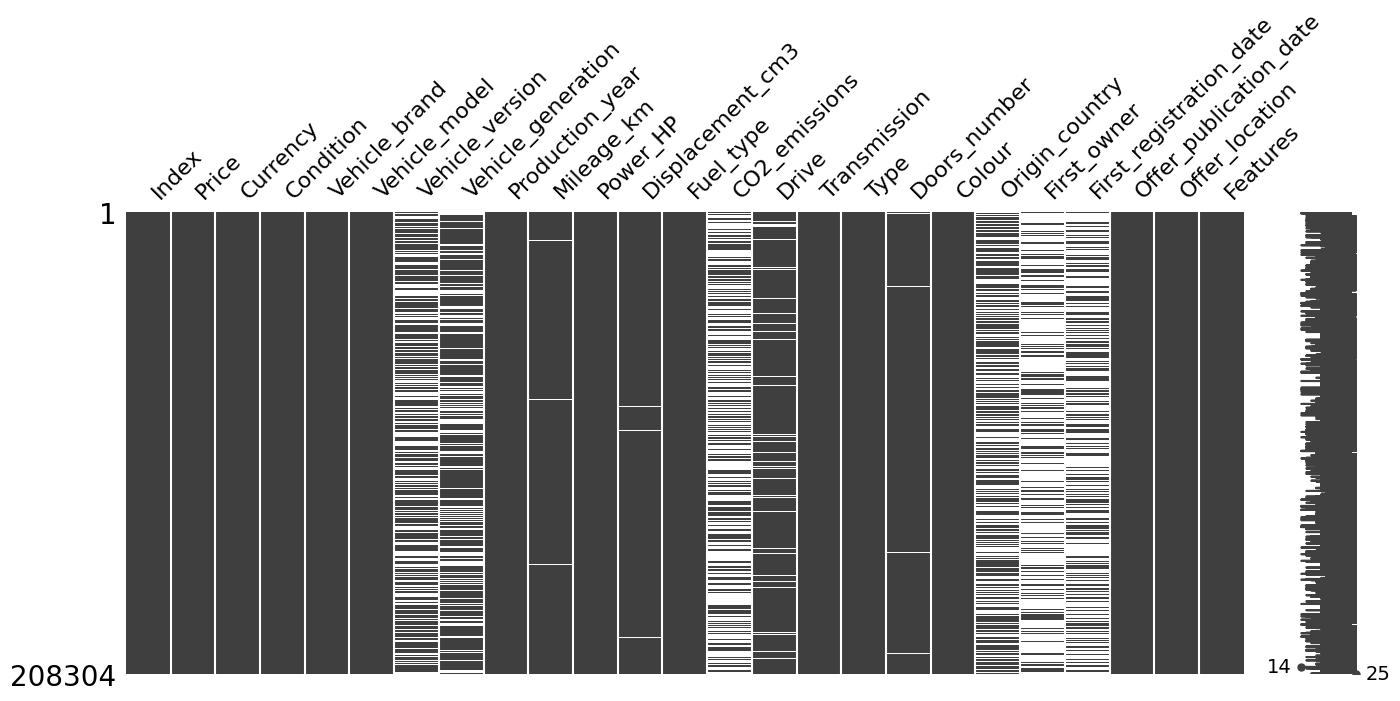

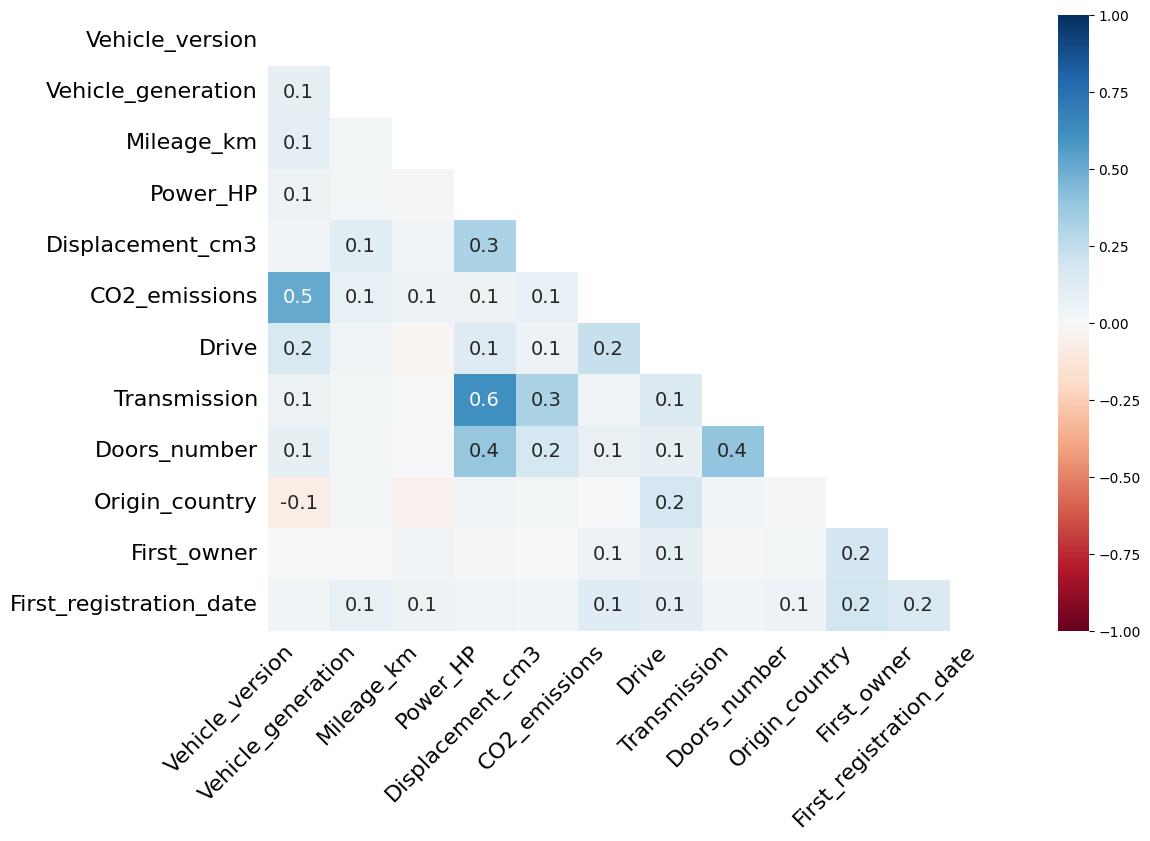

In [6]:
msno.matrix(data, figsize=(16, 6))
plt.show()

msno.heatmap(data, figsize=(12, 8))
plt.show()

In [7]:
data['First_owner'].head(20)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     Yes
6     NaN
7     Yes
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    Yes
14    NaN
15    NaN
16    NaN
17    NaN
18    Yes
19    NaN
Name: First_owner, dtype: object

#3.1.1 Kolumna "First Owner". Brak jest jednoznaczny z "No", więc trzeba to narzucić.

In [8]:
data['First_owner'] = data['First_owner'].map({'Yes': 1}).fillna(0).astype(int)

In [9]:
data['First_registration_date'].head(20)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
5     15/03/2016
6     25/02/2021
7            NaN
8            NaN
9            NaN
10           NaN
11    29/04/2010
12    09/11/2017
13           NaN
14    18/05/2015
15    27/04/2012
16           NaN
17           NaN
18           NaN
19    29/05/2009
Name: First_registration_date, dtype: object

#3.1.2 Kolumna daty pierwszej rejestracji pojazdu  nie posiada wartych uwagi korelacji a imputacja nie przyniesie żadnej pozytywnej wartości + ogromne braki = decyzja o porzuceniu tej cechy.

In [10]:
data = data.drop('First_registration_date', axis=1)

In [11]:
data['CO2_emissions'].sample(20, random_state=42)

104392      NaN
64876     184.0
27906       NaN
156533      NaN
13130     156.0
58276       NaN
56873       NaN
122154    129.0
175163      NaN
99161       NaN
33628       NaN
71603     123.0
94770       NaN
84072       NaN
86103       NaN
81636     138.0
152129     29.0
55980     139.0
45928     135.0
55791       NaN
Name: CO2_emissions, dtype: float64

#3.1.3 Kolumna emisji CO2 posiada zależności od typu silnika, pojemności silnika oraz wersji samochodu, stąd postanowienie o wykonaniu uzupełnienia braków medianą dla podobnych samochodów, stosując uzupełnienie od największych zależności, to co raz mniejsze tak aby ostatecznie uzupełnić jak najbardziej zbliżonymi realnie wartościami

In [12]:
data['CO2_emissions'] = data['CO2_emissions'].fillna(
    data.groupby(['Fuel_type', 'Displacement_cm3', 'Vehicle_version'])['CO2_emissions'].transform('median')
)

data['CO2_emissions'] = data['CO2_emissions'].fillna(
    data.groupby(['Fuel_type', 'Displacement_cm3'])['CO2_emissions'].transform('median')
)

data['CO2_emissions'] = data['CO2_emissions'].fillna(
    data.groupby(['Fuel_type'])['CO2_emissions'].transform('median')
)

data['CO2_emissions'] = data['CO2_emissions'].fillna(
    data['CO2_emissions'].median()
)

In [13]:
data['Vehicle_version'].sample(20, random_state=42)

104392                         200 d 4-Matic
64876                                    2.0
27906                                    NaN
156533                            1.5 TSI FR
13130               3.0 TDI Quattro S tronic
58276                                    NaN
56873                                    NaN
122154                               1.4 16V
175163                                   NaN
99161                      AMG 63 S 4-Matic+
33628                                    NaN
71603                              1.2 Trend
94770                                    NaN
84072                                    NaN
86103          1.6 T-GDI L Business Line DCT
81636     1.0 GSE T3 Turbo Longitude FWD S&S
152129          Grandtour E-TECH Plug-in 160
55980                           1.6 Titanium
45928                             1.2 16V 75
55791                                    NaN
Name: Vehicle_version, dtype: object

#3.1.4 Wersje samochodu to zlepek różnych informacji, nie nadający się do uzupełniania ani wzięcia pod uwagę przy trenowaniu. Decyzja o usunięciu.

In [14]:
data = data.drop(columns=['Vehicle_version'])

In [15]:
data['Vehicle_generation'].sample(20, random_state=42)

104392                    NaN
64876         Mk4 (2007-2014)
27906     E60/E61 (2003-2010)
156533           IV (2020 - )
13130          C7 (2011-2018)
58276         Mk2 (2004-2011)
56873                     NaN
122154          D (2006-2014)
175163                    NaN
99161            W213 (2016-)
33628                     NaN
71603         III (2008-2014)
94770          II (2007-2013)
84072                     NaN
86103                     NaN
81636                     NaN
152129             IV (2016-)
55980             Mk7 (2008-)
45928           I (2008-2012)
55791             Mk7 (2008-)
Name: Vehicle_generation, dtype: object

#3.1.5 Generacja pojazdu jest istotną informacją, więc nie możemy jej porzucić, ale również nie możemy uzupełnić w sensowny sposób (można pokusić się o uzupełnianie na podstawie rocznika oraz modelu ale jest ryzyko wprowadzania błędnych danych, więc pozostawiono decyzję o wprowadzeniu "Unknown", ponieważ brak informacji też jest informacją.

In [16]:
data['Vehicle_generation'] = data['Vehicle_generation'].fillna('Unknown')

In [17]:
data['Drive'].sample(20, random_state=42)

104392                 4x4 (permanent)
64876                     Front wheels
27906                      Rear wheels
156533                    Front wheels
13130                  4x4 (permanent)
58276                              NaN
56873                     Front wheels
122154                    Front wheels
175163                    Front wheels
99161                  4x4 (permanent)
33628     4x4 (attached automatically)
71603                     Front wheels
94770                     Front wheels
84072                     Front wheels
86103                     Front wheels
81636                     Front wheels
152129                    Front wheels
55980                     Front wheels
45928                     Front wheels
55791                     Front wheels
Name: Drive, dtype: object

In [18]:
pd.crosstab(
    data['Vehicle_model'],
    data['Drive']
)

Drive,4x4 (attached automatically),4x4 (attached manually),4x4 (permanent),Front wheels,Rear wheels
Vehicle_model,,,,,
1.3,0,0,0,2,0
1.5,0,0,0,0,5
1.6,0,0,0,0,4
100,0,0,2,18,0
100 NX,0,0,0,1,0
...,...,...,...,...,...
ix20,0,0,0,184,1
ix35,113,38,14,490,0
ix55,0,0,4,0,0


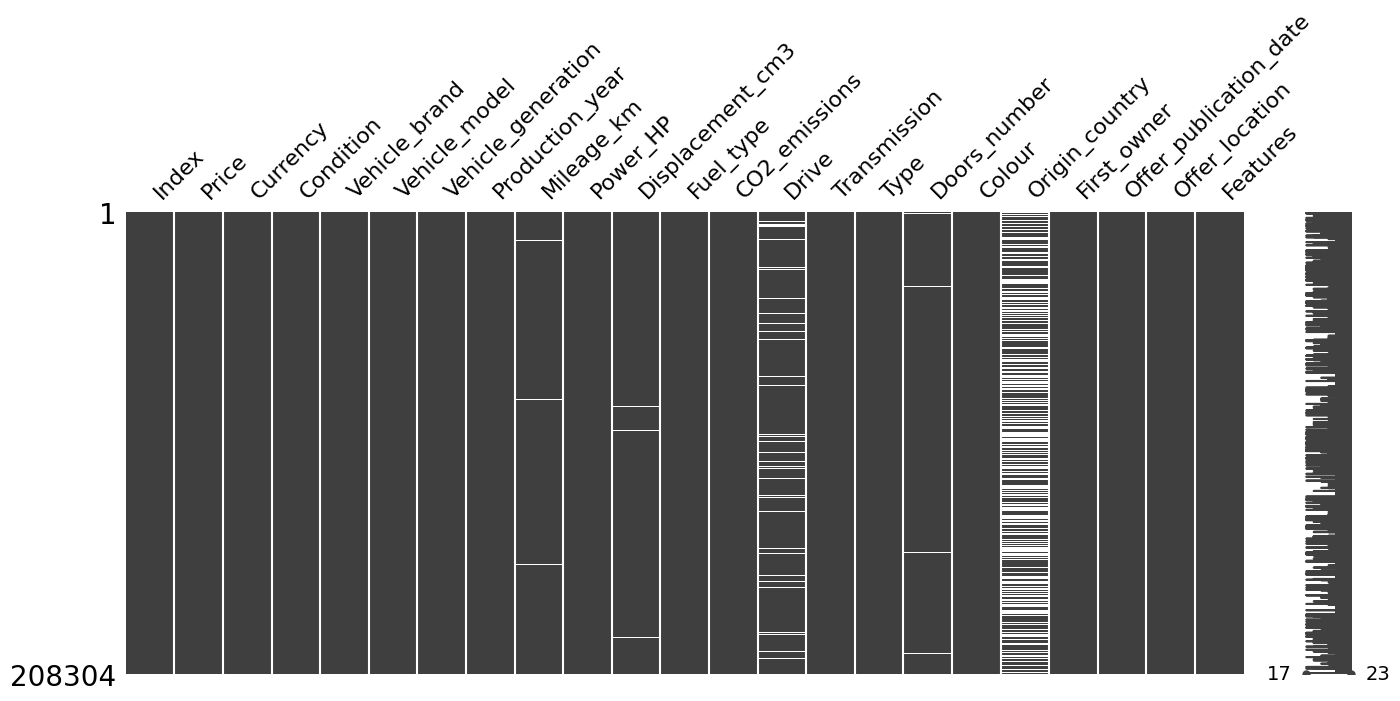

In [21]:
msno.matrix(data, figsize=(16, 6))
plt.show()

In [22]:
data['Origin_country'].value_counts(dropna=False).head(30)

Origin_country
NaN               89992
Poland            57127
Germany           38166
France             4874
United States      4099
Belgium            4055
Switzerland        2152
Netherlands        1796
Italy              1385
Austria            1218
Sweden              733
Denmark             661
Canada              596
Other               378
Czech Republic      259
Great Britain       219
Luxembourg          210
Spain               128
Finland              62
Slovakia             48
Norway               46
Slovenia             22
Russia               18
Estonia               9
Ireland               8
Greece                7
Ukraine               6
Hungary               5
Lithuania             5
Monaco                4
Name: count, dtype: int64

In [23]:
data['Origin_country'] = data['Origin_country'].fillna('Other')

In [24]:
data['Origin_country'].value_counts(dropna=False).head(30)

Origin_country
Other             90370
Poland            57127
Germany           38166
France             4874
United States      4099
Belgium            4055
Switzerland        2152
Netherlands        1796
Italy              1385
Austria            1218
Sweden              733
Denmark             661
Canada              596
Czech Republic      259
Great Britain       219
Luxembourg          210
Spain               128
Finland              62
Slovakia             48
Norway               46
Slovenia             22
Russia               18
Estonia               9
Ireland               8
Greece                7
Ukraine               6
Hungary               5
Lithuania             5
Monaco                4
Belarus               3
Name: count, dtype: int64

#3.1.6 Kolumna "Origin_country"

Kolumna posiada dużą liczbę braków. Ponieważ w danych istnieje już kategoria "Other", braki uzupełniono tą wartością. Uzupełnianie kraju pochodzenia na podstawie marki lub modelu mogłoby wprowadzać błędne dane, ponieważ ten sam model może pochodzić z różnych rynków.

In [25]:
data.isna().sum().sort_values(ascending=False)

Drive                     15076
Displacement_cm3           1966
Doors_number               1487
Mileage_km                  983
Power_HP                    643
Transmission                479
Index                         0
Vehicle_generation            0
Vehicle_model                 0
Vehicle_brand                 0
Condition                     0
Currency                      0
Price                         0
CO2_emissions                 0
Production_year               0
Fuel_type                     0
Type                          0
Colour                        0
Origin_country                0
First_owner                   0
Offer_publication_date        0
Offer_location                0
Features                      0
dtype: int64